# Tracking QC Evaluation

Use this notebook to inspect projected 2D keypoint coordinates from all six cameras alongside the matching 3D kinematic data, then summarize trial-keypoint-level tracking quality for one group. The trace plot uses absolute frame numbers; dashed vertical line marks MOC and dotted vertical line marks MOL.


In [2]:
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import KinematicPlot as kp
from group_config_new import build_groups
from tracking_qc import (
    plot_2d_keypoint_xy_traces,
    plot_tracking_qc_summary,
    summarize_tracking_qc_by_trial_keypoint,
)


## Select Trial

Set `GROUP_NAME` to either a config key from `group_config_new.py` or the group display name. Fly and trial numbers use the same 1-based indexing as the metadata Excel files.


In [4]:
GROUP_NAME = "WT_T2_TTa"
FLY = 1
TRIAL = 5
projection_path = Path(r"C:\Users\wayne\OneDrive\Desktop\AnalysisAndFigures\2DprojectionData")

OUTPUT_DIR = Path("Figures/evaluation/2D_coordinate_changes")
KEYPOINTS = ["R-fTT", "R-mTT", "R-hTT", "L-fTT", "L-mTT", "L-hTT"]
WINDOW_MODE = "moc_mol"  # "moc_mol" or "full"
VALUE_MODE = "absolute"  # "change" or "absolute"
PROJECTION_YLIM = None  # None for auto, 50 for +/-50, or e.g. (-25, 25)
XYZ_YLIM = None  # None for auto, 50 for +/-50, or e.g. (-25, 25)


6

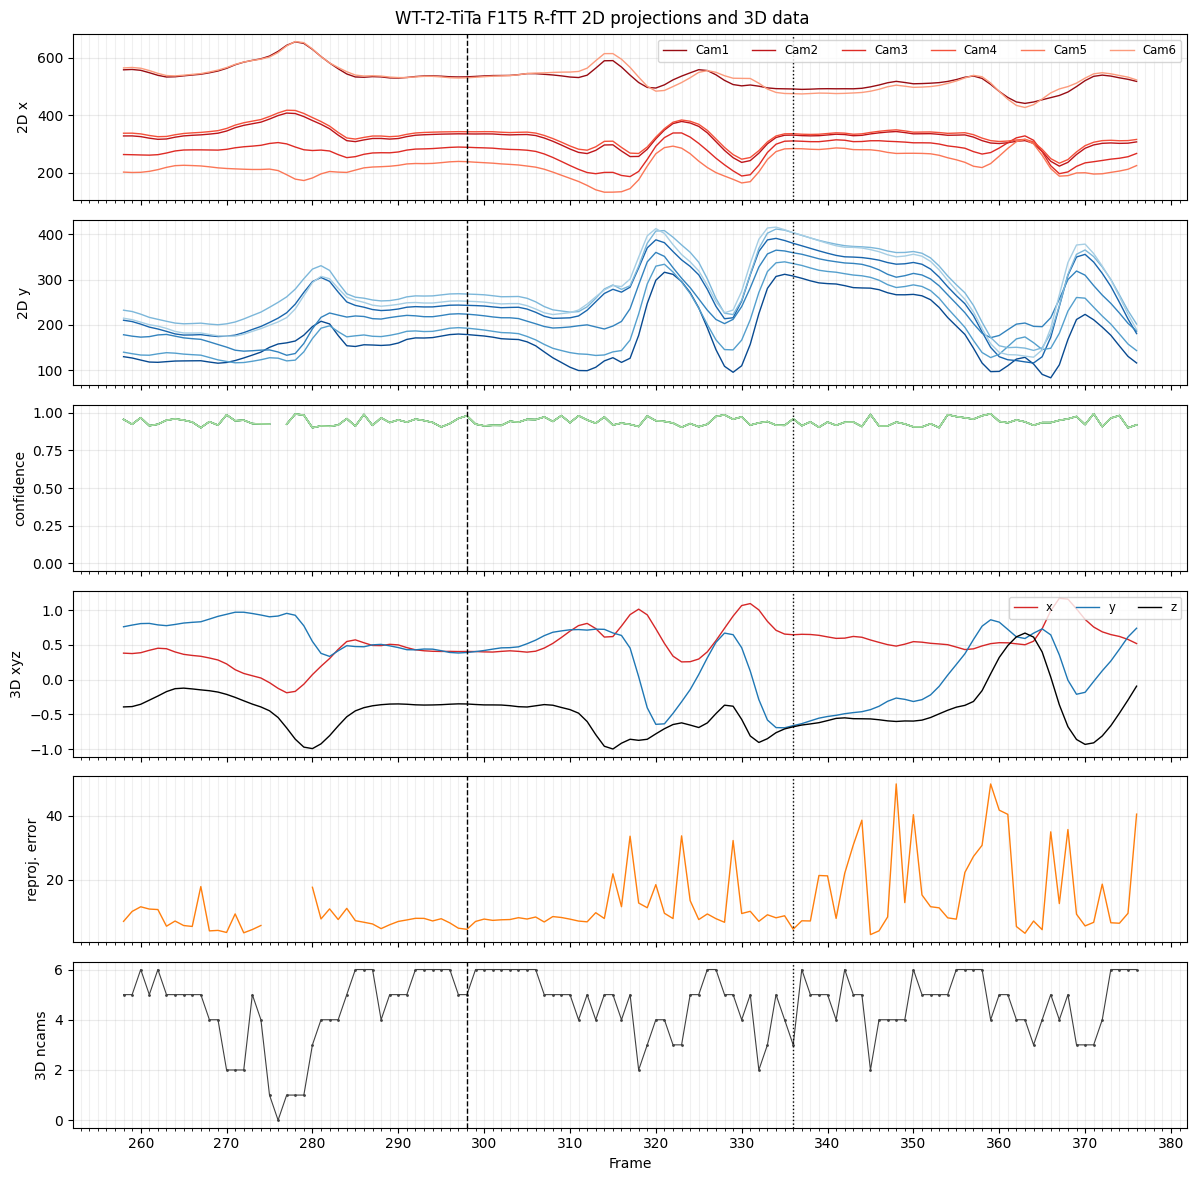

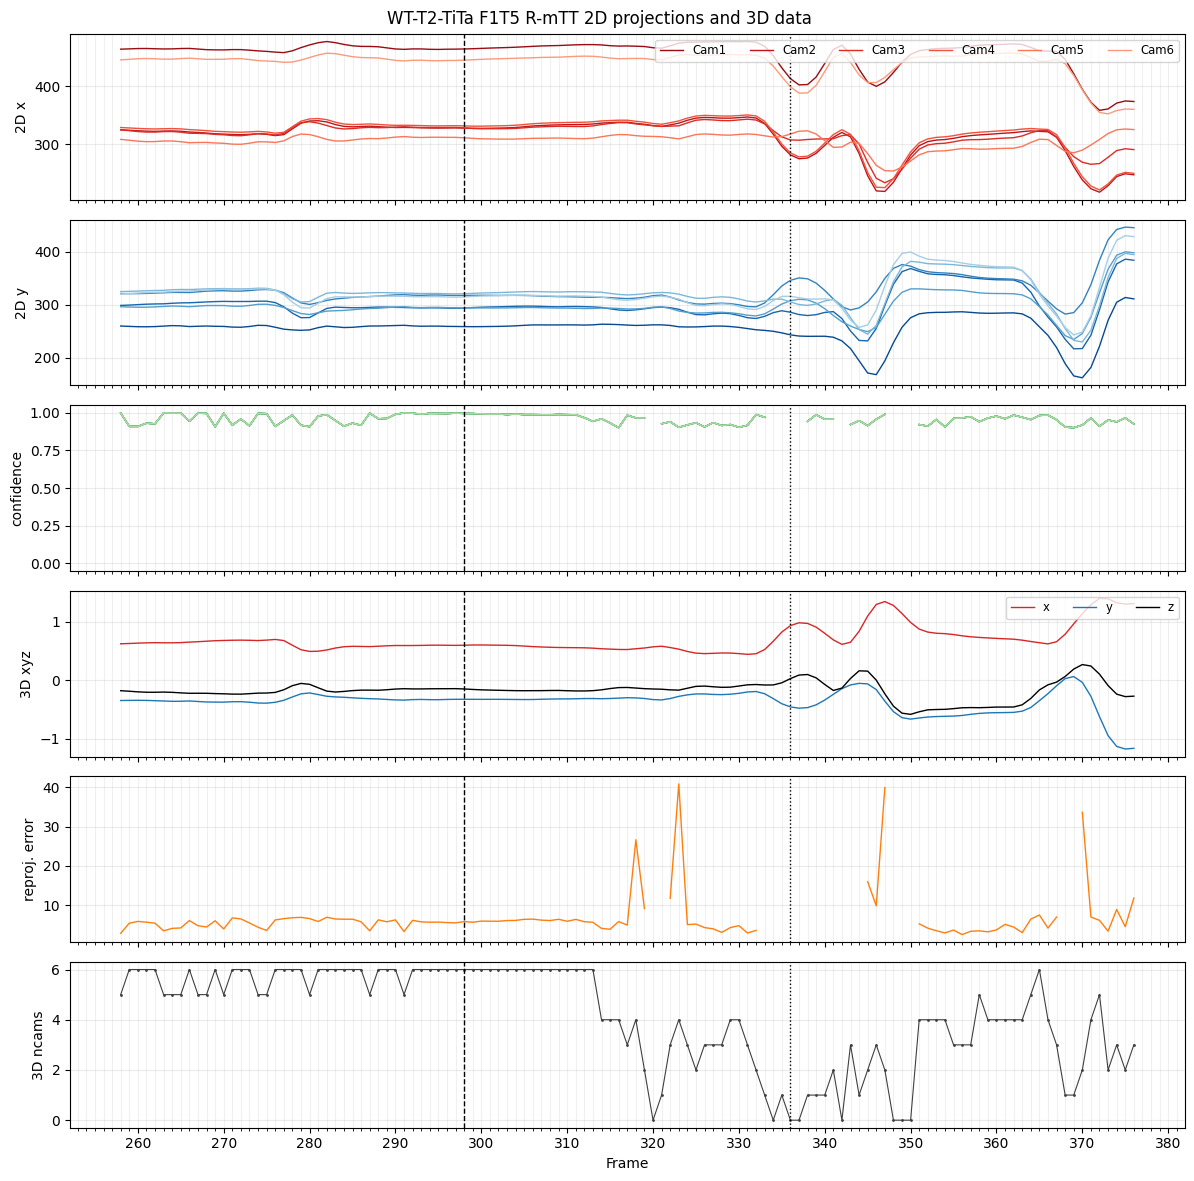

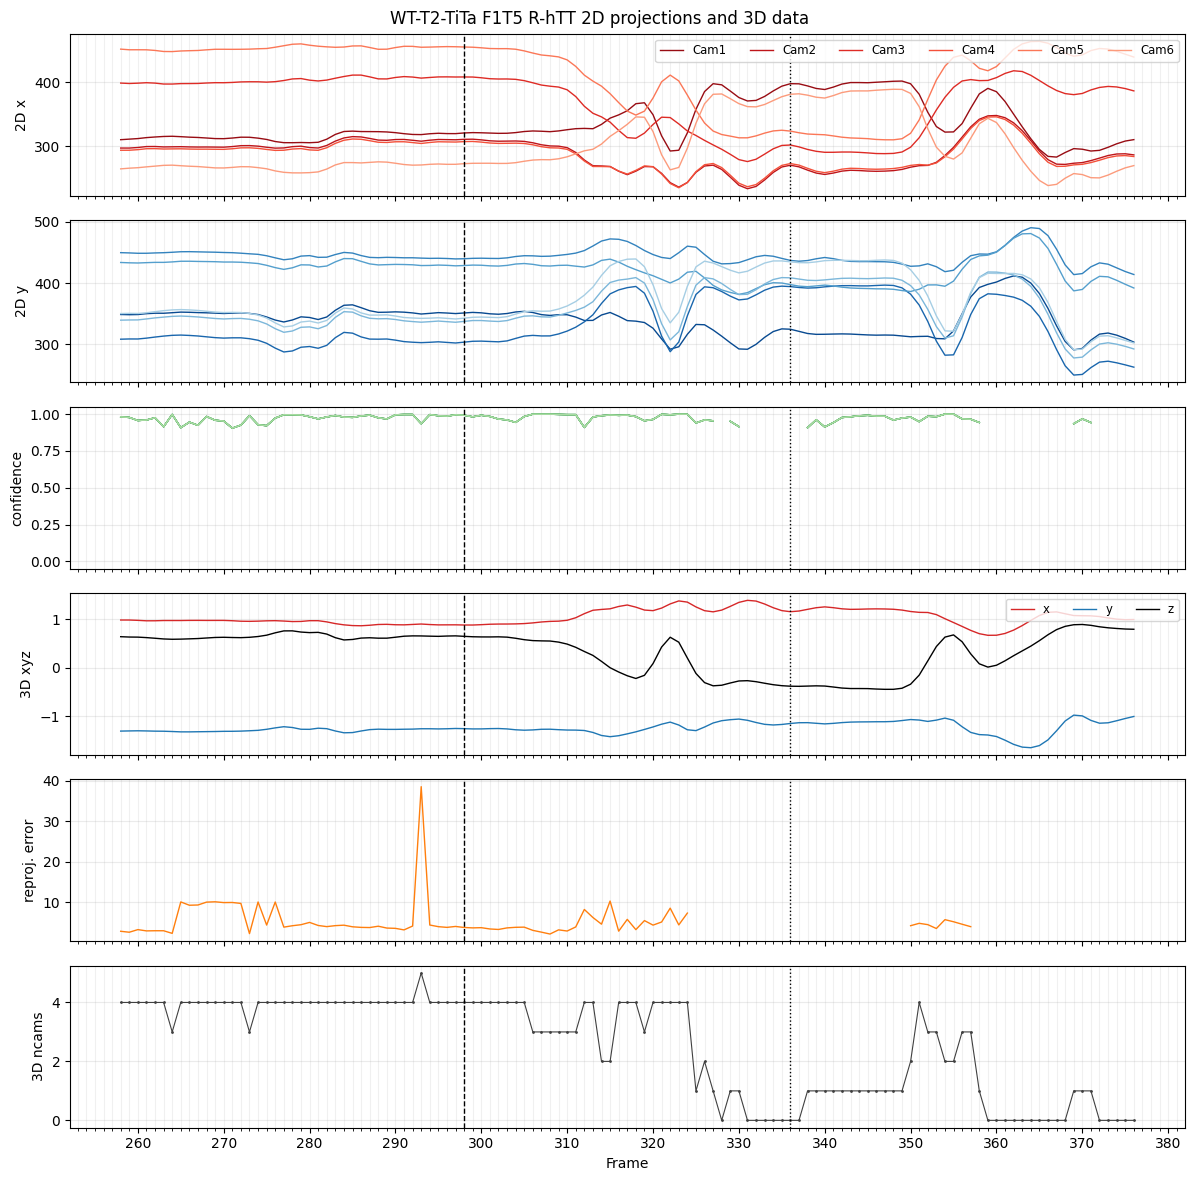

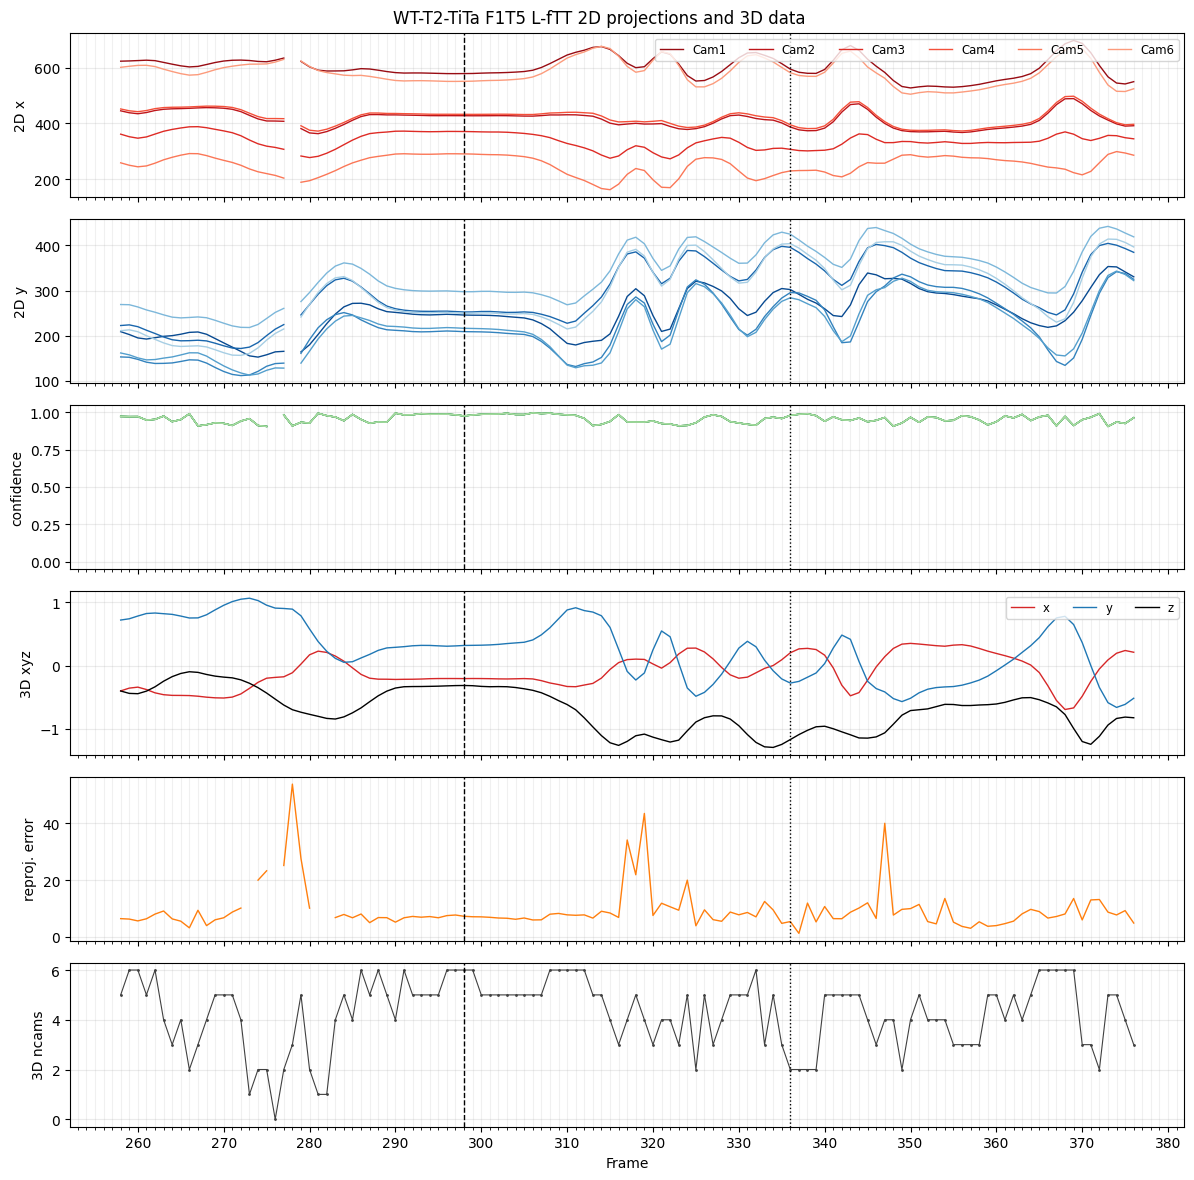

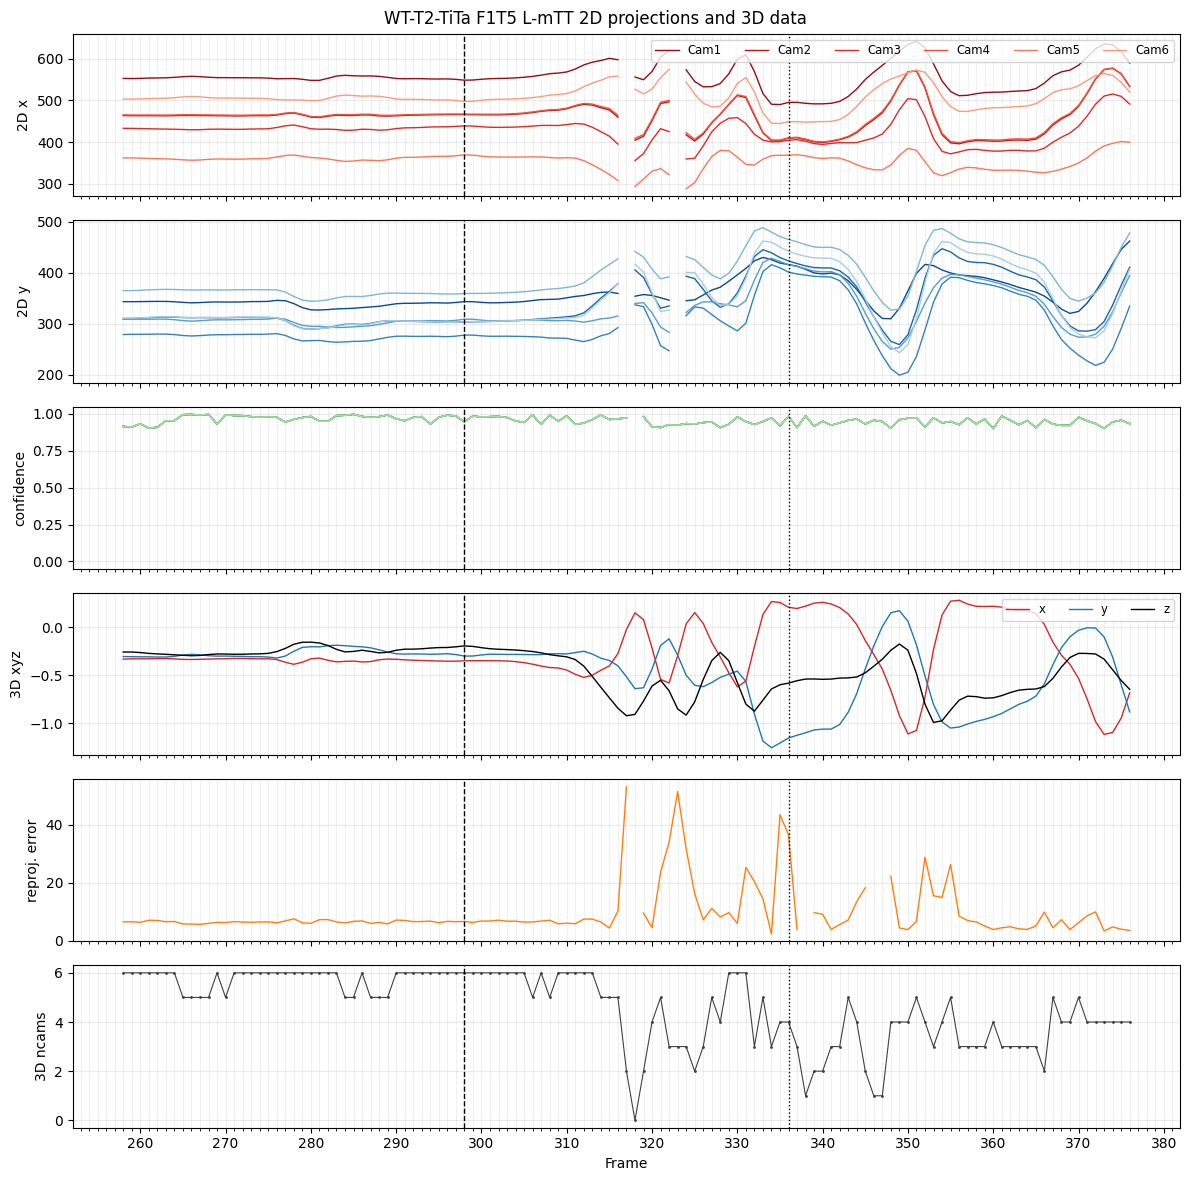

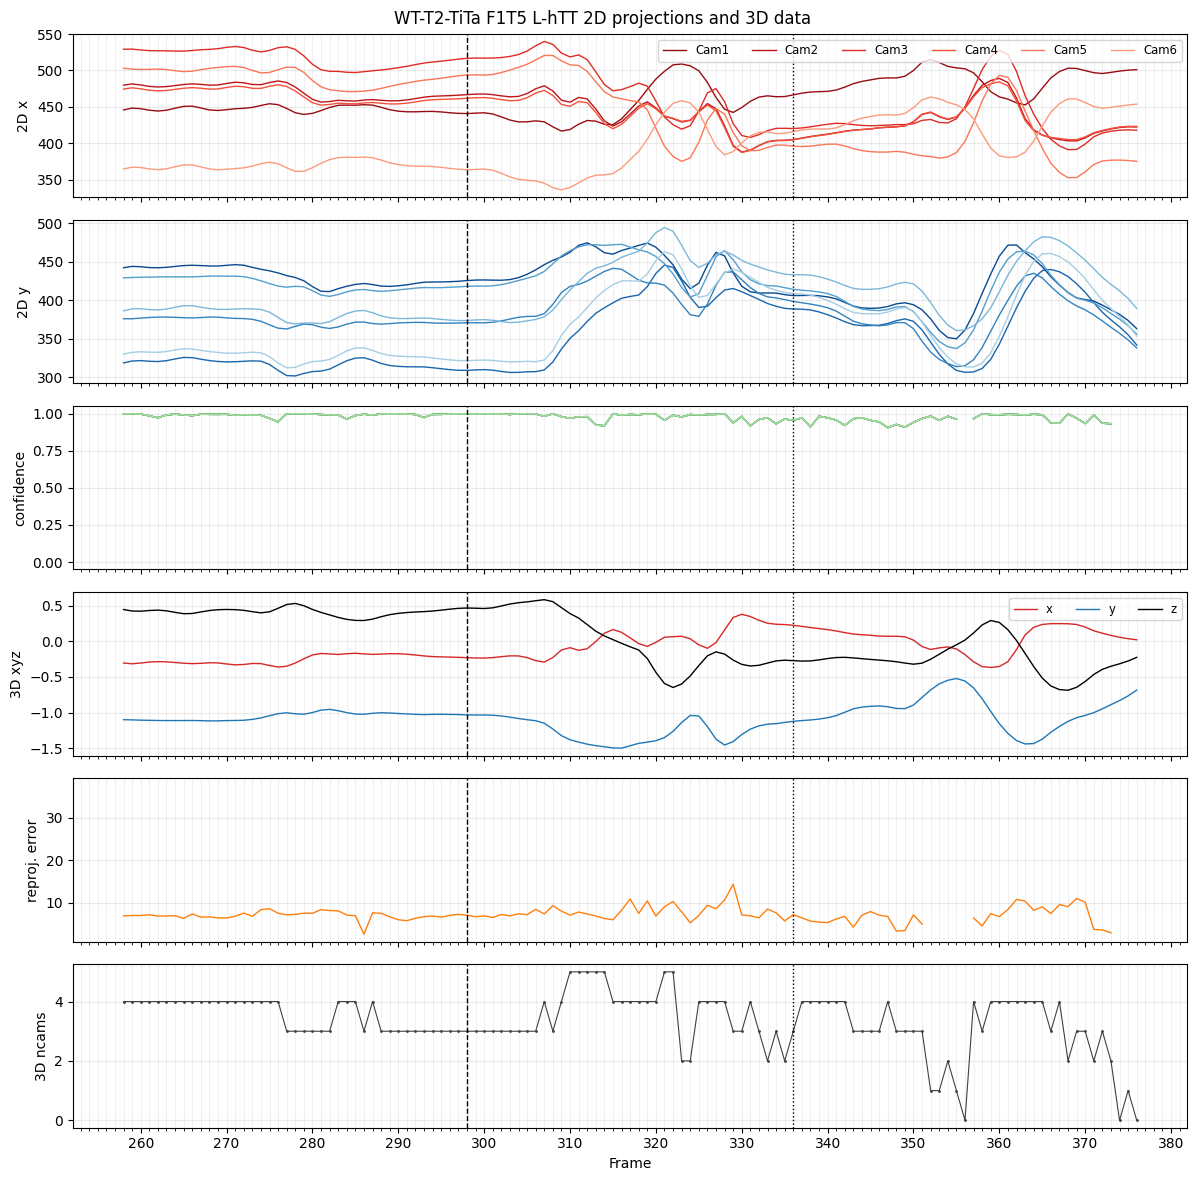

In [5]:
figures = plot_2d_keypoint_xy_traces(
    group_name=GROUP_NAME,
    fly=FLY,
    trial=TRIAL,
    projection_path=projection_path,
    keypoints=KEYPOINTS,
    window_mode=WINDOW_MODE,
    value_mode=VALUE_MODE,
    projection_ylim=PROJECTION_YLIM,
    xyz_ylim=XYZ_YLIM,
    output_dir=OUTPUT_DIR,
    show=True,
)
len(figures)


## Trial-Keypoint QC Summary

This section creates one QC row per `fly x trial x keypoint` in the selected group. Missing reprojection error, high reprojection error, low camera count, missing xyz, and low/missing score are stored separately, then combined into `Invalid_Fraction`.


In [7]:
QC_OUTPUT_DIR = Path("Figures/evaluation/QC_summary")
QC_TRIAL_TYPES = ("Landing",)  # MOC-to-MOL windows require landing trials
QC_ERROR_MAX = 50
QC_SCORE_MIN = 0.8
QC_MIN_CAMERAS = 2
QC_MAX_INTERP_GAP_FRAMES = 5
QC_MAX_INVALID_FRACTION = 0.3
QC_REQUIRE_SCORE = True  # True treats absent 3D score columns as invalid


In [8]:
qc_summary_df = summarize_tracking_qc_by_trial_keypoint(
    group_name=GROUP_NAME,
    keypoints=KEYPOINTS,
    trial_types=QC_TRIAL_TYPES,
    window_mode=WINDOW_MODE,
    error_max=QC_ERROR_MAX,
    score_min=QC_SCORE_MIN,
    min_cameras=QC_MIN_CAMERAS,
    max_interp_gap_frames=QC_MAX_INTERP_GAP_FRAMES,
    max_invalid_fraction=QC_MAX_INVALID_FRACTION,
    require_score=QC_REQUIRE_SCORE,
)

QC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
qc_summary_csv = QC_OUTPUT_DIR / f"{GROUP_NAME}_trial_keypoint_qc_summary.csv"
qc_summary_df.to_csv(qc_summary_csv, index=False)

display(qc_summary_df.head())
print(f"Saved QC summary to: {qc_summary_csv}")
skipped_trials = qc_summary_df.attrs.get("skipped_trials")
if skipped_trials is not None and len(skipped_trials) > 0:
    display(skipped_trials)


,Group,Fly,Trial,Trial_Key,Trial_Type,Keypoint,Window_Mode,Start_Frame,Stop_Frame,MOC_Frame,...,Invalid_Fraction,Interpolatable_Invalid_Frames,Interpolatable_Invalid_Fraction,Longest_Invalid_Gap_Frames,Long_Invalid_Gap_Count,Pass_Invalid_Fraction,Pass_Long_Gap,QC_Passed,Primary_Failure_Reason,Kinematic_CSV
0,WT-T2-TiTa,1,1,F1T1,Landing,R-fTT,moc_mol,443,592,483,...,0.046667,7,0.046667,5,0,True,True,True,Error_Missing,C:\Users\wayne\OneDrive\Desktop\AnalysisAndFig...
1,WT-T2-TiTa,1,1,F1T1,Landing,R-mTT,moc_mol,443,592,483,...,0.306667,28,0.186667,10,2,False,False,False,Error_Missing,C:\Users\wayne\OneDrive\Desktop\AnalysisAndFig...
2,WT-T2-TiTa,1,1,F1T1,Landing,R-hTT,moc_mol,443,592,483,...,0.020000,3,0.020000,2,0,True,True,True,Error_Missing,C:\Users\wayne\OneDrive\Desktop\AnalysisAndFig...
3,WT-T2-TiTa,1,1,F1T1,Landing,L-fTT,moc_mol,443,592,483,...,0.040000,6,0.040000,2,0,True,True,True,Error_Missing,C:\Users\wayne\OneDrive\Desktop\AnalysisAndFig...
4,WT-T2-TiTa,1,1,F1T1,Landing,L-mTT,moc_mol,443,592,483,...,0.053333,8,0.053333,3,0,True,True,True,Error_Missing,C:\Users\wayne\OneDrive\Desktop\AnalysisAndFig...


Saved QC summary to: Figures\evaluation\QC_summary\WT_T2_TTa_trial_keypoint_qc_summary.csv


['invalid_fraction',
 'missing_reprojection_error_fraction',
 'high_reprojection_error_fraction',
 'low_camera_count_fraction',
 'score_invalid_fraction',
 'interpolatable_invalid_fraction',
 'longest_invalid_gap',
 'reprojection_error_p95',
 'score_p05',
 'invalid_fraction_heatmap',
 'threshold_sensitivity']

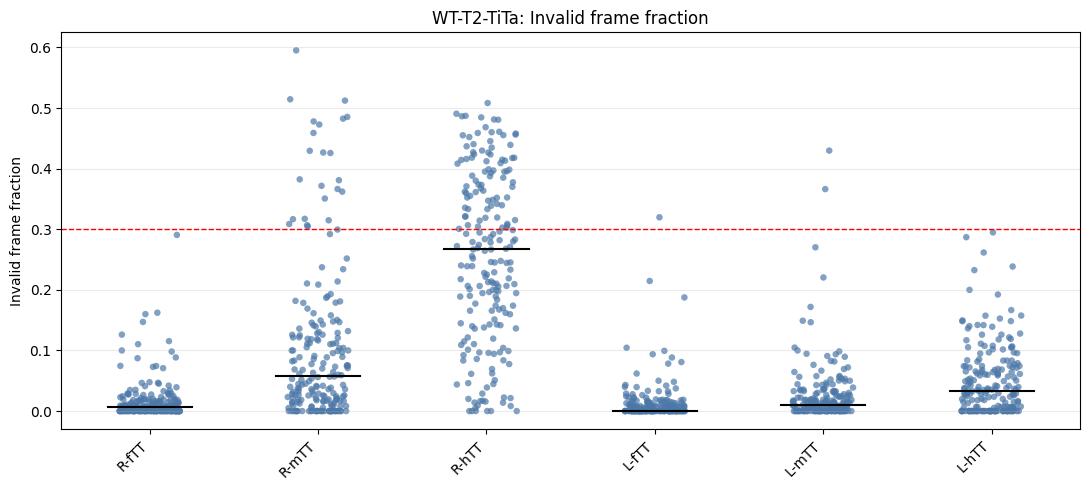

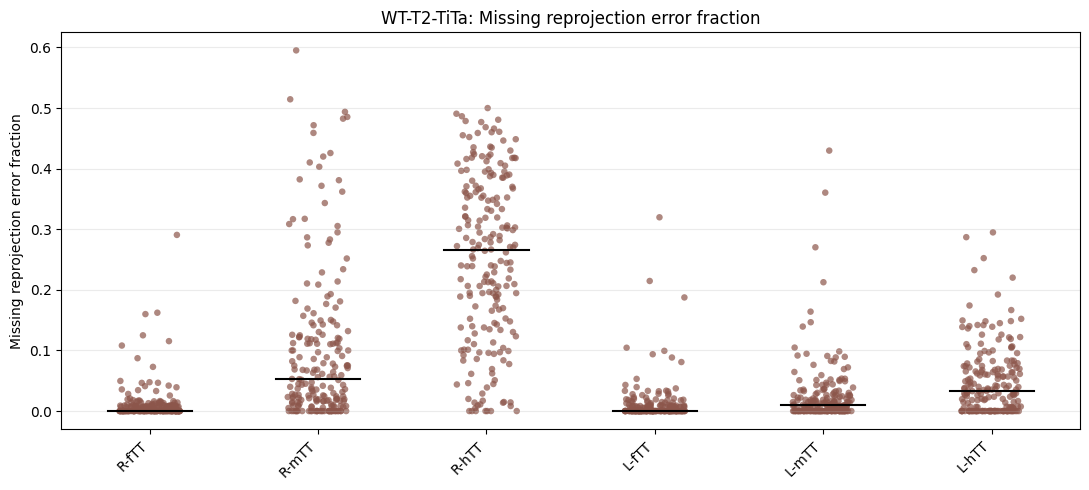

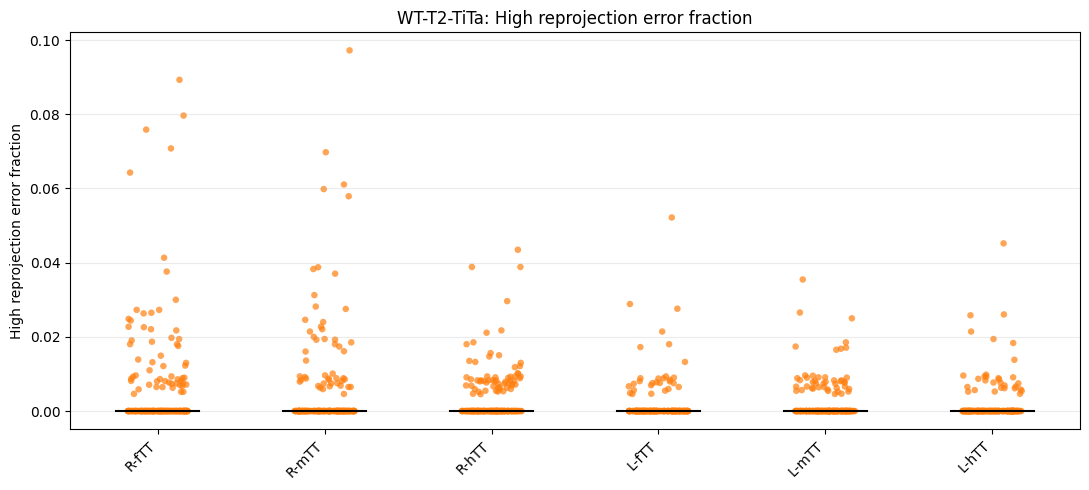

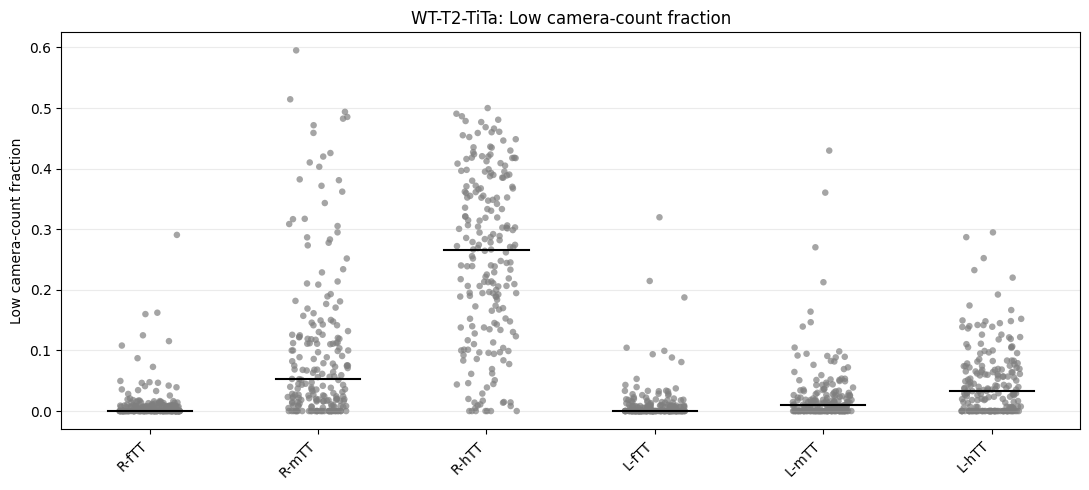

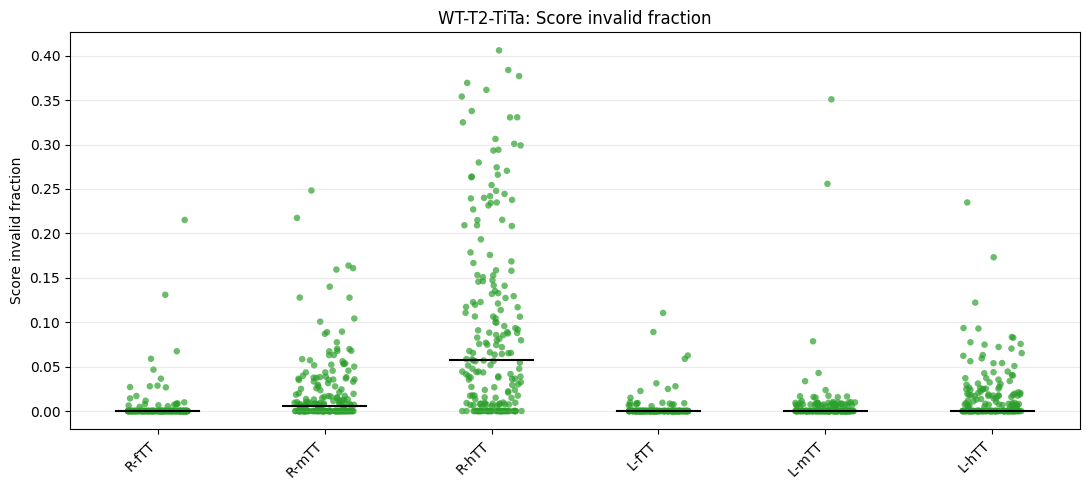

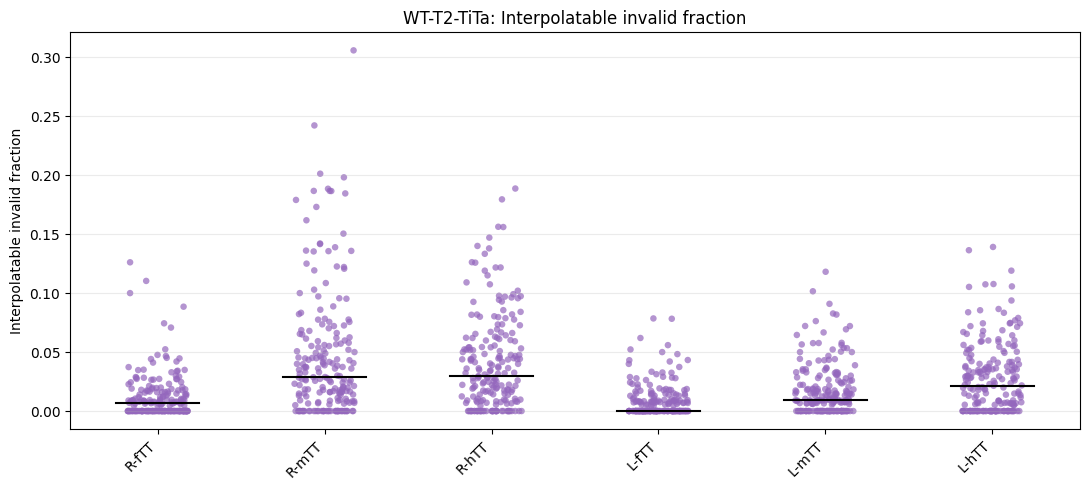

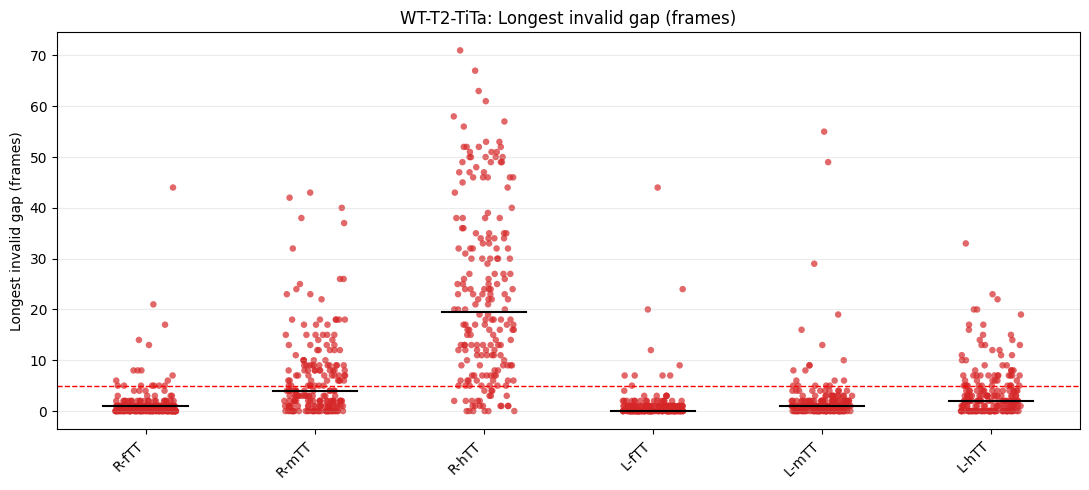

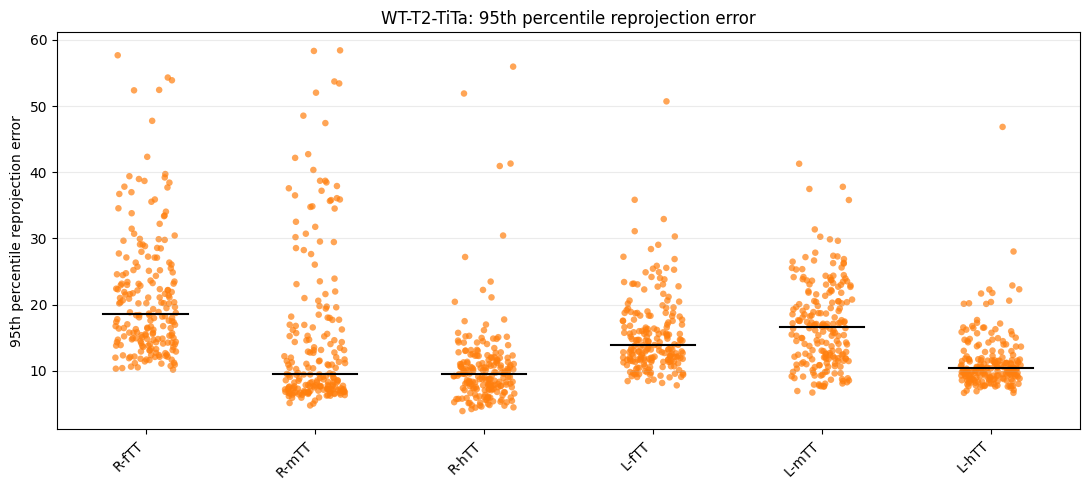

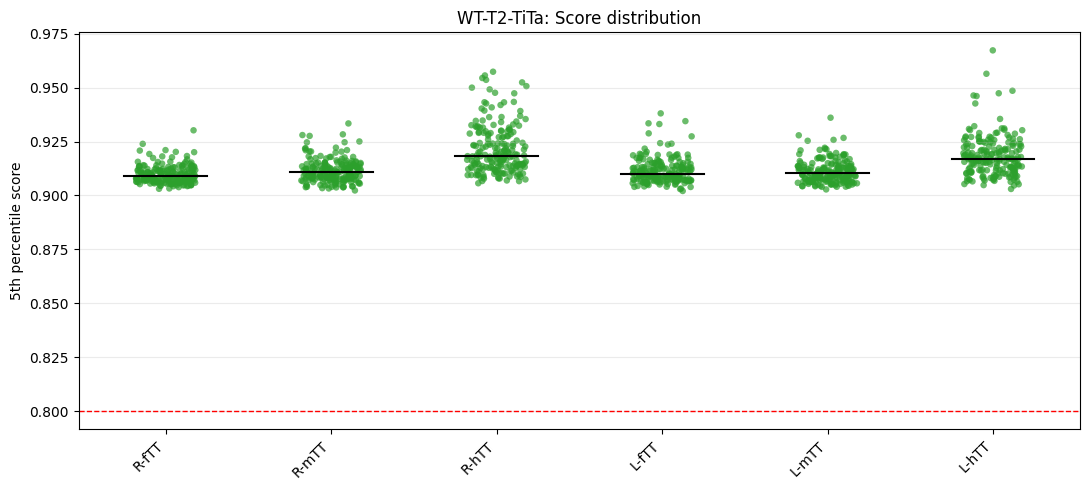

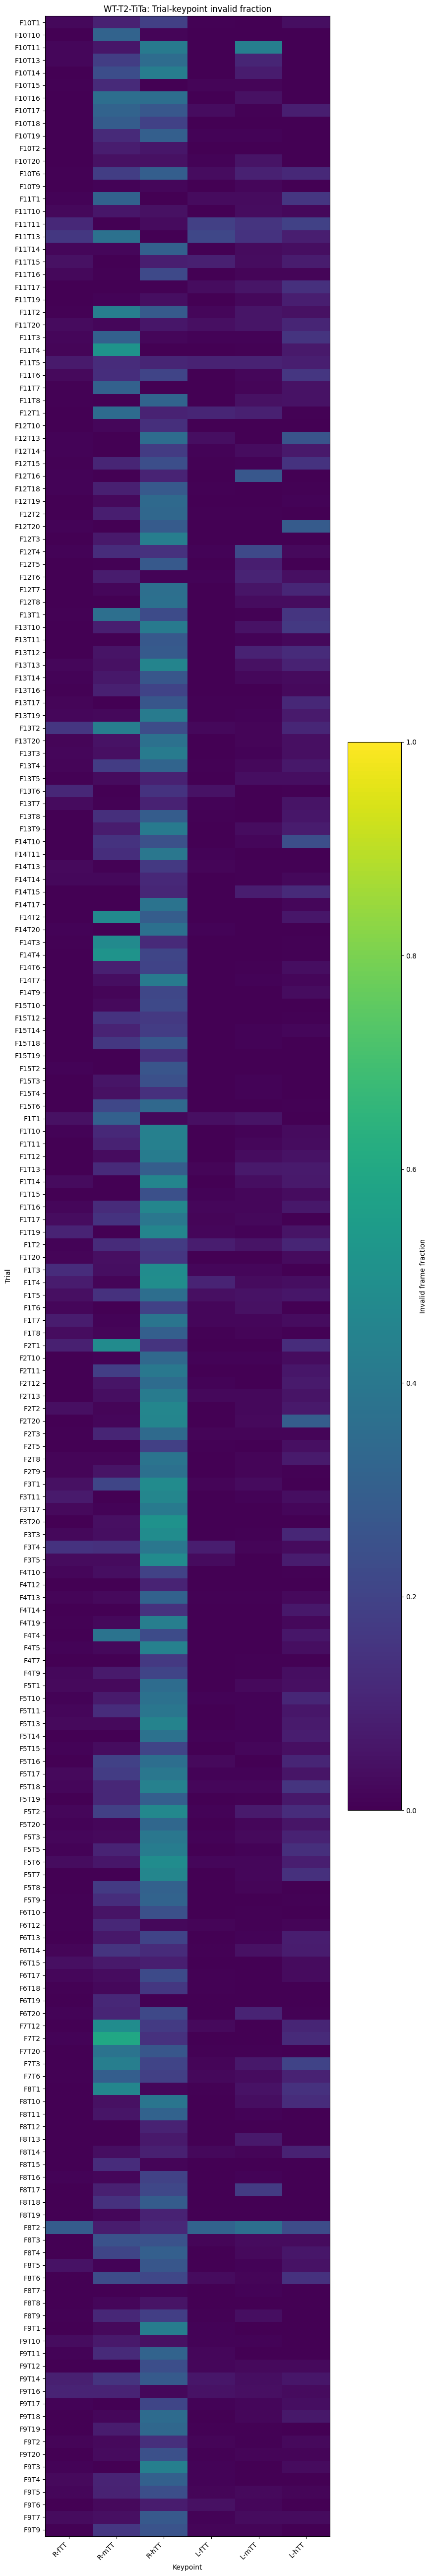

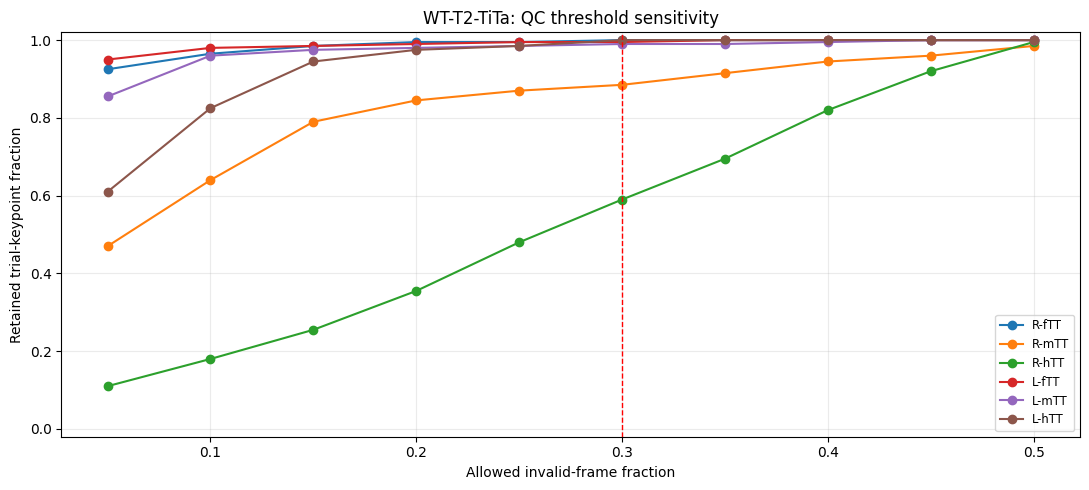

In [9]:
qc_figures = plot_tracking_qc_summary(
    qc_summary_df,
    output_dir=QC_OUTPUT_DIR,
    show=True,
    max_invalid_fraction=QC_MAX_INVALID_FRACTION,
    max_interp_gap_frames=QC_MAX_INTERP_GAP_FRAMES,
)
list(qc_figures)


## TT Trajectory QC Sensitivity

This section reruns the projected TT trajectory comparison across multiple allowed invalid-frame fractions. It collects the returned fly-mean vector permutation p-values and plots p-value versus QC threshold.


In [11]:
TT_SENS_OUTPUT_DIR = Path("Figures/evaluation/TT_QC_sensitivity")
TT_SENS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# X-axis values for the sensitivity plot. The analysis call receives
# min_valid_fraction = 1 - Max_Invalid_Fraction.
TT_SENS_MAX_INVALID_FRACTIONS = np.array([0.10, 0.20, 0.30, 0.40, 0.50])

# This reruns a permutation test for every threshold. Reduce while testing,
# then restore to 20000 for final output if runtime is acceptable.
TT_SENS_N_PERM = 20000
TT_SENS_RANDOM_STATE = 0

TT_SENS_MIN_CAMERAS = 2
TT_SENS_MAX_INTERP_GAP_FRAMES = 5
TT_SENS_TT_JOINTS = ("L-fTT", "L-mTT", "L-hTT")
TT_SENS_PLANE_AXIS = ("R-mBC", "L-mBC")
TT_SENS_ORIGIN_KEYPOINT = "R-mBC"

TT_SENS_GROUP_KEYS = ["WT_T1_TTa", "WT_T2_TTa", "WT_T3_TTa"]
TT_SENS_GROUPS_BY_KEY = build_groups(
    group_keys=TT_SENS_GROUP_KEYS,
    skip_missing=False,
    require_kinematics=False,
)
TT_SENS_GROUPS = {
    "T1": TT_SENS_GROUPS_BY_KEY["WT_T1_TTa"],
    "T2": TT_SENS_GROUPS_BY_KEY["WT_T2_TTa"],
    "T3": TT_SENS_GROUPS_BY_KEY["WT_T3_TTa"],
}
TT_SENS_SC_CSV_PATHS = {
    "T1": Path("SC data") / "WT-T1-TiTa_LegContact.csv",
    "T2": Path("SC data") / "WT-T2-TiTa_LegContact.csv",
    "T3": Path("SC data") / "WT-T3-TiTa_LegContact.csv",
}

tt_sens_plotter = kp.PlotCreator(
    platform_offset=0.07,
    platform_height=0.1,
    radius=0.03,
    fps=250,
)


In [12]:
tt_sensitivity_stats = []
tt_sensitivity_errors = []

for max_invalid_fraction in TT_SENS_MAX_INVALID_FRACTIONS:
    min_valid_fraction = 1.0 - float(max_invalid_fraction)
    try:
        (
            _,
            _,
            point_df,
            trajectory_df,
            radial_df,
            radial_stats_df,
            skipped_df,
        ) = tt_sens_plotter.plot_TT_MOC_to_SLC_endpoint_projected_combined(
            group_info=TT_SENS_GROUPS,
            sc_csv_paths=TT_SENS_SC_CSV_PATHS,
            tt_joints=TT_SENS_TT_JOINTS,
            plane_axis=TT_SENS_PLANE_AXIS,
            origin_keypoint=TT_SENS_ORIGIN_KEYPOINT,
            trial_types=("Landing", "Flying"),
            tau=0.71,
            axis_average_frames=100,
            axis_average_anchor="moc",
            file_name=None,
            target_fps=250,
            trajectory_average_mode="absolute_time",
            n_perm=TT_SENS_N_PERM,
            random_state=TT_SENS_RANDOM_STATE,
            apply_tracking_qc=True,
            tracking_error_thresholds=None,
            min_cameras=TT_SENS_MIN_CAMERAS,
            max_interp_gap_frames=TT_SENS_MAX_INTERP_GAP_FRAMES,
            min_valid_fraction=min_valid_fraction,
            save_csv=False,
        )
        stats = radial_stats_df.copy()
        stats["Max_Invalid_Fraction"] = float(max_invalid_fraction)
        stats["Min_Valid_Fraction"] = min_valid_fraction
        stats["n_point_rows"] = len(point_df)
        stats["n_trajectory_rows"] = len(trajectory_df)
        stats["n_radial_rows"] = len(radial_df)
        stats["n_skipped_rows"] = len(skipped_df)
        tt_sensitivity_stats.append(stats)
    except Exception as exc:
        tt_sensitivity_errors.append({
            "Max_Invalid_Fraction": float(max_invalid_fraction),
            "Min_Valid_Fraction": min_valid_fraction,
            "Error": f"{type(exc).__name__}: {exc}",
        })

tt_sensitivity_stats_df = (
    pd.concat(tt_sensitivity_stats, ignore_index=True)
    if tt_sensitivity_stats
    else pd.DataFrame()
)
tt_sensitivity_errors_df = pd.DataFrame(tt_sensitivity_errors)

tt_sensitivity_stats_path = TT_SENS_OUTPUT_DIR / "TT_trajectory_QC_invalid_fraction_sensitivity_stats.csv"
tt_sensitivity_errors_path = TT_SENS_OUTPUT_DIR / "TT_trajectory_QC_invalid_fraction_sensitivity_errors.csv"
tt_sensitivity_stats_df.to_csv(tt_sensitivity_stats_path, index=False)
tt_sensitivity_errors_df.to_csv(tt_sensitivity_errors_path, index=False)

display(tt_sensitivity_stats_df)
if not tt_sensitivity_errors_df.empty:
    display(tt_sensitivity_errors_df)


C:\Users\wayne\OneDrive\Desktop\AnalysisAndFigures\plot_geometry.py:775: RuntimeWarning: Mean of empty slice
  mean_x = np.nanmean(np.asarray(x_stack, dtype=float), axis=0)
C:\Users\wayne\OneDrive\Desktop\AnalysisAndFigures\plot_geometry.py:776: RuntimeWarning: Mean of empty slice
  mean_y = np.nanmean(np.asarray(y_stack, dtype=float), axis=0)
C:\Users\wayne\OneDrive\Desktop\AnalysisAndFigures\plot_geometry.py:775: RuntimeWarning: Mean of empty slice
  mean_x = np.nanmean(np.asarray(x_stack, dtype=float), axis=0)
C:\Users\wayne\OneDrive\Desktop\AnalysisAndFigures\plot_geometry.py:776: RuntimeWarning: Mean of empty slice
  mean_y = np.nanmean(np.asarray(y_stack, dtype=float), axis=0)
C:\Users\wayne\OneDrive\Desktop\AnalysisAndFigures\plot_geometry.py:775: RuntimeWarning: Mean of empty slice
  mean_x = np.nanmean(np.asarray(x_stack, dtype=float), axis=0)
C:\Users\wayne\OneDrive\Desktop\AnalysisAndFigures\plot_geometry.py:776: RuntimeWarning: Mean of empty slice
  mean_y = np.nanmean(np.a

,Joint,Leg,Group_A,Group_B,Test,Primary_Statistic,Observed_Vector_Distance,Vector_Permutation_P,Observed_Delta_X_GroupB_minus_GroupA,Observed_Delta_Y_GroupB_minus_GroupA,...,Group_A_n_trials,Group_B_n_trials,n_perm,random_state,Max_Invalid_Fraction,Min_Valid_Fraction,n_point_rows,n_trajectory_rows,n_radial_rows,n_skipped_rows
0,L-fTT,L-f,T1,T2,fly_mean_vector_label_shuffle,distance_between_group_mean_vectors,0.240658,0.000900,0.121972,-0.207459,...,227,182,20000,0,0.1,0.9,6712,123012,1678,164
1,L-fTT,L-f,T1,T3,fly_mean_vector_label_shuffle,distance_between_group_mean_vectors,0.254015,0.000100,-0.253204,-0.020283,...,227,185,20000,0,0.1,0.9,6712,123012,1678,164
2,L-fTT,L-f,T2,T3,fly_mean_vector_label_shuffle,distance_between_group_mean_vectors,0.419275,0.000050,-0.375176,0.187176,...,182,185,20000,0,0.1,0.9,6712,123012,1678,164
3,L-mTT,L-m,T1,T2,fly_mean_vector_label_shuffle,distance_between_group_mean_vectors,0.225259,0.000050,0.098119,-0.202766,...,205,161,20000,0,0.1,0.9,6712,123012,1678,164
4,L-mTT,L-m,T1,T3,fly_mean_vector_label_shuffle,distance_between_group_mean_vectors,0.435751,0.000050,0.267555,-0.343938,...,205,157,20000,0,0.1,0.9,6712,123012,1678,164
5,L-mTT,L-m,T2,T3,fly_mean_vector_label_shuffle,distance_between_group_mean_vectors,0.220540,0.000050,0.169435,-0.141171,...,161,157,20000,0,0.1,0.9,6712,123012,1678,164
6,L-hTT,L-h,T1,T2,fly_mean_vector_label_shuffle,distance_between_group_mean_vectors,0.148550,0.067397,0.003434,-0.148510,...,218,174,20000,0,0.1,0.9,6712,123012,1678,164
7,L-hTT,L-h,T1,T3,fly_mean_vector_label_shuffle,distance_between_group_mean_vectors,0.555768,0.000050,0.549214,0.085103,...,218,169,20000,0,0.1,0.9,6712,123012,1678,164
8,L-hTT,L-h,T2,T3,fly_mean_vector_label_shuffle,distance_between_group_mean_vectors,0.593676,0.000050,0.545780,0.233613,...,174,169,20000,0,0.1,0.9,6712,123012,1678,164
9,L-fTT,L-f,T1,T2,fly_mean_vector_label_shuffle,distance_between_group_mean_vectors,0.241415,0.000900,0.122118,-0.208250,...,228,182,20000,0,0.2,0.8,6796,124345,1699,143


WindowsPath('Figures/evaluation/TT_QC_sensitivity/TT_trajectory_QC_invalid_fraction_sensitivity_pvalues.pdf')

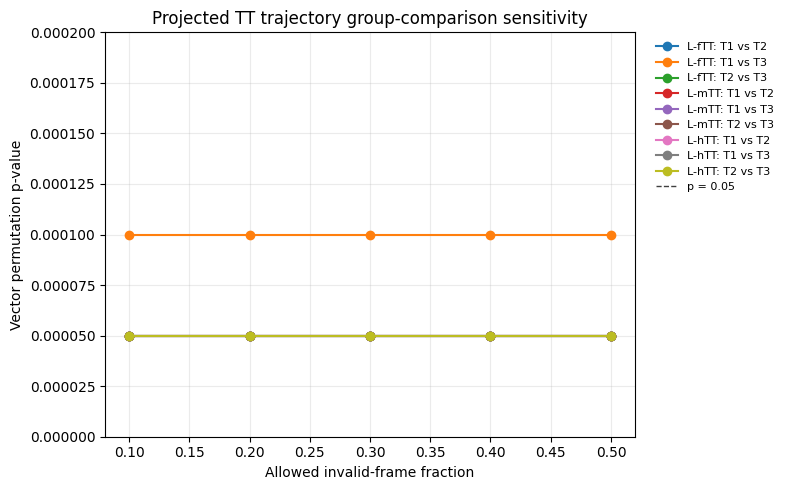

In [37]:
if tt_sensitivity_stats_df.empty:
    raise ValueError("No TT sensitivity statistics were generated.")

fig, ax = plt.subplots(figsize=(8, 5))
for (joint, group_a, group_b), sub in tt_sensitivity_stats_df.groupby(["Joint", "Group_A", "Group_B"], sort=False):
    sub = sub.sort_values("Max_Invalid_Fraction")
    ax.plot(
        sub["Max_Invalid_Fraction"],
        sub["Vector_Permutation_P"],
        marker="o",
        linewidth=1.5,
        label=f"{joint}: {group_a} vs {group_b}",
    )

ax.axhline(0.05, color="0.25", linestyle="--", linewidth=1, label="p = 0.05")
ax.set_xlabel("Allowed invalid-frame fraction")
ax.set_ylabel("Vector permutation p-value")
ax.set_title("Projected TT trajectory group-comparison sensitivity")
ax.set_ylim(0, 0.0002)
ax.grid(True, alpha=0.25)
ax.legend(frameon=False, fontsize=8, ncol=1, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()

tt_sensitivity_plot_path = TT_SENS_OUTPUT_DIR / "TT_trajectory_QC_invalid_fraction_sensitivity_pvalues.pdf"
fig.savefig(tt_sensitivity_plot_path, dpi=300, bbox_inches="tight")
tt_sensitivity_plot_path
